# EXFOR Module Test Notebook

This notebook demonstrates all functionality of the simplified EXFOR module in kika.

**Module Structure:**
- `ExforEntry` - Base class with metadata as plain dicts
- `ExforAngularDistribution` - Angular distribution data with frame/unit conversion

**Main Functions:**
- `read_exfor()` - Load a single EXFOR JSON file
- `read_all_exfor()` - Load all EXFOR files from a directory

## 1. Setup & Imports

In [1]:
# Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# EXFOR module imports
from kika.exfor import (
    read_exfor,
    read_all_exfor,
    ExforEntry,
    ExforAngularDistribution,
)

# Transform functions
from kika.exfor import (
    cos_cm_from_cos_lab,
    cos_lab_from_cos_cm,
    transform_lab_to_cm,
    transform_cm_to_lab,
)

# Plotting functions
from kika.exfor import plot_exfor_angular, plot_exfor_ace_comparison

print("All imports successful!")
print(f"ExforEntry: {ExforEntry}")
print(f"ExforAngularDistribution: {ExforAngularDistribution}")

All imports successful!
ExforEntry: <class 'kika.exfor.exfor_entry.ExforEntry'>
ExforAngularDistribution: <class 'kika.exfor.angular_distribution.ExforAngularDistribution'>


In [2]:
# Define data paths
DATA_DIR = '/share_snc/snc/JuanMonleon/EXFOR/data'
DATA_V1_DIR = '/share_snc/snc/JuanMonleon/EXFOR/data_v1'

# Sample files
SAMPLE_FILE = f'{DATA_DIR}/27673002.json'  # TOF data, LAB frame, MeV
SAMPLE_FILE_V1 = f'{DATA_V1_DIR}/27673002.json'  # v1 format

## 2. Loading Data

In [3]:
# Load a single EXFOR file
exfor = read_exfor(SAMPLE_FILE)

print(f"Type: {type(exfor).__name__}")
print(f"Entry: {exfor.entry}")
print(f"Subentry: {exfor.subentry}")
print(f"Quantity: {exfor.quantity}")

Type: ExforAngularDistribution
Entry: 27673
Subentry: 27673002
Quantity: DA


In [4]:
# Load v1 format file (should work identically)
exfor_v1 = read_exfor(SAMPLE_FILE_V1)

print(f"v1 format loaded: {exfor_v1.label}")
print(f"Same number of energies: {len(exfor.energies())} vs {len(exfor_v1.energies())}")

v1 format loaded: Gkatis et al. (2025)
Same number of energies: 127 vs 127


In [5]:
# Access raw data blocks (internal attribute)
exfor_v1._data_blocks[:2]  # First 2 energy blocks

[{'value': 1.0098,
  'data': [{'angle': -0.9603,
    'cross_section': 0.0943,
    'uncertainty_stat': 0.0073},
   {'angle': -0.7967, 'cross_section': 0.112, 'uncertainty_stat': 0.0064},
   {'angle': -0.5255, 'cross_section': 0.0945, 'uncertainty_stat': 0.006},
   {'angle': -0.1834, 'cross_section': 0.0711, 'uncertainty_stat': 0.0053},
   {'angle': 0.1834, 'cross_section': 0.1205, 'uncertainty_stat': 0.0051},
   {'angle': 0.5255, 'cross_section': 0.2275, 'uncertainty_stat': 0.0097},
   {'angle': 0.7967, 'cross_section': 0.4224, 'uncertainty_stat': 0.016},
   {'angle': 0.9603, 'cross_section': 0.5738, 'uncertainty_stat': 0.0273}]},
 {'value': 1.0202,
  'data': [{'angle': -0.9603,
    'cross_section': 0.1302,
    'uncertainty_stat': 0.0085},
   {'angle': -0.7967, 'cross_section': 0.1152, 'uncertainty_stat': 0.0066},
   {'angle': -0.5255, 'cross_section': 0.082, 'uncertainty_stat': 0.0051},
   {'angle': -0.1834, 'cross_section': 0.0497, 'uncertainty_stat': 0.0041},
   {'angle': 0.1834, 'cr

## 3. Properties & Dict Access

The simplified module stores metadata as plain dicts but provides convenient properties.

In [6]:
# Convenience properties
print("=== Properties ===")
print(f"label:       {exfor.label}")
print(f"target:      {exfor.target}")
print(f"zaid:        {exfor.zaid}")
print(f"target_mass: {exfor.target_mass:.4f} amu")
print(f"process:     {exfor.process}")
print(f"projectile:  {exfor.projectile}")

=== Properties ===
label:       Gkatis et al. (2025)
target:      Fe56
zaid:        26056
target_mass: 55.9349 amu
process:     EL
projectile:  n


In [7]:
# Direct dict access for full metadata
print("=== Citation (dict) ===")
print(f"Authors: {exfor.citation.get('authors', [])}")
print(f"Year: {exfor.citation.get('year')}")
print(f"Title: {exfor.citation.get('title', 'N/A')[:80]}...")
print(f"References: {exfor.citation.get('references', [])}")

=== Citation (dict) ===
Authors: ['G. Gkatis', 'M. Diakaki', 'G. Noguere', 'A. Oprea', 'C. Paradela', 'E. Pirovano', 'A. J. M. Plompen']
Year: 2025
Title: Double-differential-cross-section measurements of neutron scattering on 56Fe...
References: ['Physical Review C 112 (2025) 044603', 'DOI:10.1103/b5n2-9kxn', 'URL=https://journals.aps.org/prc/abstract/10.1103/b5n2-9kxn']


In [8]:
# Reaction information
print("=== Reaction (dict) ===")
print(f"Target: {exfor.reaction.get('target')}")
print(f"Target ZAID: {exfor.reaction.get('target_zaid')}")
print(f"Projectile: {exfor.reaction.get('projectile')}")
print(f"Process: {exfor.reaction.get('process')}")
print(f"Notation: {exfor.reaction.get('notation')}")

=== Reaction (dict) ===
Target: Fe56
Target ZAID: 26056
Projectile: n
Process: EL
Notation: 26-FE-56(N,EL)26-FE-56


In [9]:
# Facility and Method
print("=== Facility (dict) ===")
print(f"Type: {exfor.facility.get('type')}")
print(f"Code: {exfor.facility.get('code')}")
print(f"Name: {exfor.facility.get('name')}")

print("\n=== Method (dict) ===")
print(f"Type: {exfor.method.get('type')}")
print(f"Energy resolution inputs: {exfor.method.get('energy_resolution_input') or exfor.method.get('energy_resolution_inputs')}")

=== Facility (dict) ===
Type: LINAC
Code: 2ZZZGEL
Name: GELINA

=== Method (dict) ===
Type: TOF
Energy resolution inputs: {'distance': {'value': 27.037, 'uncertainty': 0.005, 'unit': 'm', 'ref': 'source_to_scatter'}, 'time_resolution': {'value': 10.0, 'unit': 'ns'}}


In [10]:
# Detector and Sample (raw dicts)
print("=== Detector (dict) ===")
if exfor.detector:
    print(f"Keys: {list(exfor.detector.keys())}")
else:
    print("No detector info")

print("\n=== Sample (dict) ===")
if exfor.sample:
    print(f"Keys: {list(exfor.sample.keys())}")
else:
    print("No sample info")

=== Detector (dict) ===
Keys: ['scintillators', 'fission_chamber']

=== Sample (dict) ===
No sample info


In [11]:
# Units and frame info (specific to ExforAngularDistribution)
print("=== Angular Distribution Specifics ===")
print(f"Angle frame: {exfor.angle_frame}")
print(f"Units: {exfor.units}")

=== Angular Distribution Specifics ===
Angle frame: LAB
Units: {'energy': 'MeV', 'angle': 'cos', 'cross_section': 'b/sr'}


## 4. Data Access with `to_dataframe()`

The primary method for accessing data is `to_dataframe()`, which returns a clean DataFrame with:
- `energy`: Energy value in requested units
- `angle`: Angle value in requested units  
- `value`: Cross-section value in requested units
- `error`: Total uncertainty (stat + sys combined)

### New Unified Filter API

The new API uses unified parameters:
- `energy`: float for single value (5% tolerance) or tuple for range
- `angle`: float for single value (5% tolerance) or tuple for range
- `tolerance`: relative tolerance for single-value matching (default: 0.05)

In [12]:
# Get available energies using the new energies() method
energies_arr = exfor.energies()  # Returns numpy array in MeV by default
energies_kev = exfor.energies(unit='keV')

print(f"Number of energies: {len(energies_arr)}")
print(f"Energy range: {energies_arr.min():.4f} - {energies_arr.max():.4f} MeV")
print(f"First 5 energies (MeV): {energies_arr[:5]}")
print(f"First 5 energies (keV): {energies_kev[:5]}")

# Filter by bounds
energies_filtered = exfor.energies(unit='MeV', bounds=(1.0, 2.0))
print(f"\nEnergies in [1.0, 2.0] MeV: {len(energies_filtered)}")

Number of energies: 127
Energy range: 1.0098 - 7.8464 MeV
First 5 energies (MeV): [1.0098 1.0202 1.0307 1.0414 1.0522]
First 5 energies (keV): [1009.8 1020.2 1030.7 1041.4 1052.2]

Energies in [1.0, 2.0] MeV: 57


In [13]:
# Get all data as DataFrame
df = exfor.to_dataframe()

print(f"All data: {len(df)} points")
print(f"Columns: {list(df.columns)}")
df.head()

All data: 1016 points
Columns: ['energy', 'angle', 'value', 'error']


,energy,angle,value,error
0,1.0098,163.801297,0.0943,0.0073
1,1.0098,142.816121,0.1120,0.0064
2,1.0098,121.701909,0.0945,0.0060
3,1.0098,100.567863,0.0711,0.0053
4,1.0098,79.432137,0.1205,0.0051


In [14]:
# Filter by energy (returns data at E ~ 1.5 MeV with 10% tolerance)
df_energy = exfor.to_dataframe(energy=1.5, tolerance=0.1)

print(f"Data at E ~ 1.5 MeV: {len(df_energy)} points")
df_energy

Data at E ~ 1.5 MeV: 128 points


,energy,angle,value,error
0,1.3567,163.801297,0.1302,0.0064
1,1.3567,142.816121,0.1170,0.0048
2,1.3567,121.701909,0.0648,0.0040
3,1.3567,100.567863,0.0502,0.0035
4,1.3567,79.432137,0.0889,0.0035
...,...,...,...,...
123,1.6326,100.567863,0.0817,0.0057
124,1.6326,79.432137,0.0737,0.0030
125,1.6326,58.298091,0.1708,0.0065
126,1.6326,37.183879,0.4379,0.0176


In [15]:
# Filter by energy range (tuple)
df_range = exfor.to_dataframe(energy=(1.0, 2.0))

print(f"Data in [1.0, 2.0] MeV: {len(df_range)} points")
print(f"Unique energies: {sorted(df_range['energy'].unique())}")
df_range.head()

Data in [1.0, 2.0] MeV: 456 points
Unique energies: [np.float64(1.0098), np.float64(1.0202), np.float64(1.0307), np.float64(1.0414), np.float64(1.0522), np.float64(1.0633), np.float64(1.0744), np.float64(1.0857), np.float64(1.0973), np.float64(1.109), np.float64(1.1209), np.float64(1.133), np.float64(1.1453), np.float64(1.1578), np.float64(1.1705), np.float64(1.1834), np.float64(1.1966), np.float64(1.21), np.float64(1.2235), np.float64(1.2373), np.float64(1.2513), np.float64(1.2656), np.float64(1.2801), np.float64(1.295), np.float64(1.3099), np.float64(1.3253), np.float64(1.3409), np.float64(1.3567), np.float64(1.3728), np.float64(1.3892), np.float64(1.406), np.float64(1.423), np.float64(1.4403), np.float64(1.4579), np.float64(1.4759), np.float64(1.4943), np.float64(1.5129), np.float64(1.5319), np.float64(1.5513), np.float64(1.5709), np.float64(1.5911), np.float64(1.6117), np.float64(1.6326), np.float64(1.6539), np.float64(1.6756), np.float64(1.6977), np.float64(1.7203), np.float64(1.7

,energy,angle,value,error
0,1.0098,163.801297,0.0943,0.0073
1,1.0098,142.816121,0.1120,0.0064
2,1.0098,121.701909,0.0945,0.0060
3,1.0098,100.567863,0.0711,0.0053
4,1.0098,79.432137,0.1205,0.0051


In [16]:
# With unit conversion
df_converted = exfor.to_dataframe(energy_unit='keV', cross_section_unit='mb/sr')

print(f"Columns: {list(df_converted.columns)}")
print(f"First energy: {df_converted.iloc[0]['energy']:.1f} keV")
print(f"First cross section: {df_converted.iloc[0]['value']:.3f} mb/sr")
df_converted.head()

Columns: ['energy', 'angle', 'value', 'error']
First energy: 1009.8 keV
First cross section: 94.300 mb/sr


,energy,angle,value,error
0,1009.8,163.801297,94.3,7.3
1,1009.8,142.816121,112.0,6.4
2,1009.8,121.701909,94.5,6.0
3,1009.8,100.567863,71.1,5.3
4,1009.8,79.432137,120.5,5.1


In [17]:
# Filter by angle range (forward angles only) - use tuple
df_forward = exfor.to_dataframe(angle=(0, 90))

print(f"Forward angles (0-90 deg): {len(df_forward)} points")
df_forward.head()

Forward angles (0-90 deg): 508 points


,energy,angle,value,error
0,1.0098,79.432137,0.1205,0.0051
1,1.0098,58.298091,0.2275,0.0097
2,1.0098,37.183879,0.4224,0.0160
3,1.0098,16.198703,0.5738,0.0273
4,1.0202,79.432137,0.0733,0.0032


## 5. Frame Conversion (LAB <-> CM)

In [18]:
# Convert to CM frame (returns new object by default)
print(f"Original frame: {exfor.angle_frame}")

exfor_cm = exfor.convert_to_cm()

print(f"CM frame object: {exfor_cm.angle_frame}")
print(f"Original unchanged: {exfor.angle_frame}")

Original frame: LAB
CM frame object: CM
Original unchanged: LAB


In [19]:
# Compare data in both frames using to_dataframe
energy = exfor.energies()[0]
df_lab = exfor.to_dataframe(energy=energy)
df_cm = exfor_cm.to_dataframe(energy=energy)

print("LAB frame (first 3 points):")
print(df_lab[['angle', 'value']].head(3))
print("\nCM frame (first 3 points):")
print(df_cm[['angle', 'value']].head(3))
print("\n(Note: angles and cross sections differ due to frame transformation)")

LAB frame (first 3 points):
        angle   value
0  163.801297  0.0943
1  142.816121  0.1120
2  121.701909  0.0945

CM frame (first 3 points):
        angle     value
0  164.089531  0.097654
1  143.440577  0.115296
2  122.580988  0.096328

(Note: angles and cross sections differ due to frame transformation)


In [20]:
# In-place conversion
exfor_copy = read_exfor(SAMPLE_FILE)
print(f"Before: {exfor_copy.angle_frame}")

result = exfor_copy.convert_to_cm(inplace=True)

print(f"After: {exfor_copy.angle_frame}")
print(f"Return value: {result}  (None for inplace)")

Before: LAB
After: CM
Return value: None  (None for inplace)


In [21]:
# Convert back to LAB
exfor_back = exfor_cm.convert_to_lab()

print(f"CM -> LAB: {exfor_back.angle_frame}")

# Compare with original using to_dataframe
energy = exfor.energies()[0]
df_original = exfor.to_dataframe(energy=energy)
df_back = exfor_back.to_dataframe(energy=energy)

print("\nOriginal LAB angles:", df_original['angle'].values[:3])
print("Roundtrip LAB angles:", df_back['angle'].values[:3])
print("(Small numerical differences expected)")

CM -> LAB: LAB

Original LAB angles: [163.80129681 142.81612107 121.70190911]
Roundtrip LAB angles: [163.80129681 142.81612107 121.70190911]
(Small numerical differences expected)


## 6. Unit Conversion

In [22]:
# Convert energy units
print(f"Original energy unit: {exfor.units['energy']}")
print(f"First energy: {exfor.energies()[0]}")

exfor_kev = exfor.convert_energy('keV')

print(f"\nConverted to keV:")
print(f"Energy unit: {exfor_kev.units['energy']}")
print(f"First energy: {exfor_kev.energies()[0]}")

Original energy unit: MeV
First energy: 1.0098

Converted to keV:
Energy unit: keV
First energy: 1.0098


In [23]:
# Convert cross section units
energy = exfor.energies()[0]
print(f"Original XS unit: {exfor.units['cross_section']}")
df_original = exfor.to_dataframe(energy=energy)
print(f"First XS value: {df_original.iloc[0]['value']:.6f}")

exfor_mb = exfor.convert_cross_section('mb/sr')

print(f"\nConverted to mb/sr:")
print(f"XS unit: {exfor_mb.units['cross_section']}")
df_mb = exfor_mb.to_dataframe(energy=energy)
print(f"First XS value: {df_mb.iloc[0]['value']:.3f}")
print(f"\n(Example: 0.0943 b/sr = 94.3 mb/sr)")

Original XS unit: b/sr
First XS value: 0.094300

Converted to mb/sr:
XS unit: mb/sr
First XS value: 0.094

(Example: 0.0943 b/sr = 94.3 mb/sr)


In [24]:
# Convert angle units (deg <-> cos)
energy = exfor.energies()[0]
df_original = exfor.to_dataframe(energy=energy)

print(f"Original angle unit: {exfor.units['angle']}")
print(f"First angle: {df_original.iloc[0]['angle']}")

# Use to_dataframe with angle_unit conversion
df_cos = exfor.to_dataframe(energy=energy, angle_unit='cos')

print(f"\nConverted to cos(theta) using to_dataframe:")
print(f"First angle (cos): {df_cos.iloc[0]['angle']:.4f}")

# Alternatively, convert the object
exfor_deg = exfor.convert_angle('deg')
print(f"\nUsing convert_angle() method:")
print(f"Angle unit: {exfor_deg.units['angle']}")

Original angle unit: cos
First angle: 163.80129680891915

Converted to cos(theta) using to_dataframe:
First angle (cos): -0.9603

Using convert_angle() method:
Angle unit: deg


## 7. New angles() Method and Combined Filters

In [25]:
# Get available angles using the new angles() method
all_angles = exfor.angles()  # Returns numpy array in degrees by default

print(f"=== angles() Method ===")
print(f"Number of unique angles: {len(all_angles)}")
print(f"Angle range: {all_angles.min():.2f} - {all_angles.max():.2f} degrees")
print(f"Angles (deg): {all_angles}")

# Get angles in cosine units
angles_cos = exfor.angles(unit='cos')
print(f"\nAngles (cos): {angles_cos}")

# Get angles at specific energy
angles_at_e = exfor.angles(energy=1.5)
print(f"\nAngles at E~1.5 MeV: {len(angles_at_e)} unique values")

=== angles() Method ===
Number of unique angles: 8
Angle range: 16.20 - 163.80 degrees
Angles (deg): [ 16.19870319  37.18387893  58.29809089  79.43213681 100.56786319
 121.70190911 142.81612107 163.80129681]

Angles (cos): [-0.9603 -0.7967 -0.5255 -0.1834  0.1834  0.5255  0.7967  0.9603]

Angles at E~1.5 MeV: 8 unique values


In [26]:
# Combined energy and angle filters
df_combined = exfor.to_dataframe(energy=1.5, angle=(0, 90))

print("=== Combined Filters ===")
print(f"Data at E~1.5 MeV with forward angles (0-90 deg): {len(df_combined)} points")
df_combined.head()

# Alternative: use tuples for both
df_ranges = exfor.to_dataframe(energy=(1.0, 2.0), angle=(45, 135))
print(f"\nData in E=[1.0, 2.0] MeV, angle=[45, 135] deg: {len(df_ranges)} points")

=== Combined Filters ===
Data at E~1.5 MeV with forward angles (0-90 deg): 32 points

Data in E=[1.0, 2.0] MeV, angle=[45, 135] deg: 228 points


## 8. Energy Resolution (TOF Experiments)

In [27]:
# Check energy resolution input parameters
eri = exfor.method.get('energy_resolution_input') or exfor.method.get('energy_resolution_inputs')

print("=== Energy Resolution Input Parameters ===")
if eri:
    distance = eri.get('distance', {})
    time_res = eri.get('time_resolution', {})
    print(f"Flight path: {distance.get('value')} {distance.get('unit', 'm')}")
    print(f"Time resolution: {time_res.get('value')} {time_res.get('unit', 'ns')}")
else:
    print("No energy resolution input data available")

=== Energy Resolution Input Parameters ===
Flight path: 27.037 m
Time resolution: 10.0 ns


In [28]:
# Compute energy resolution at different energies
test_energies = [0.5, 1.0, 2.0, 5.0]  # MeV

print("=== Computed Energy Resolution ===")
print(f"{'Energy (MeV)':<15} {'sigma_E (MeV)':<15} {'sigma_E/E (%)':<15}")
print("-" * 45)

for e in test_energies:
    sigma_E = exfor.compute_energy_resolution(e)
    if sigma_E is not None:
        rel_res = 100 * sigma_E / e
        print(f"{e:<15.1f} {sigma_E:<15.6f} {rel_res:<15.2f}")
    else:
        print(f"{e:<15.1f} {'N/A':<15} {'N/A':<15}")

=== Computed Energy Resolution ===
Energy (MeV)    sigma_E (MeV)   sigma_E/E (%)  
---------------------------------------------
0.5             0.003617        0.72           
1.0             0.010232        1.02           
2.0             0.028939        1.45           
5.0             0.114393        2.29           


In [29]:
# Explain the formula
print("""
Energy Resolution Formula (TOF):
================================
For time-of-flight experiments:
  sigma_E/E = 2 * sigma_t / t

Where:
  t = L/v (time of flight)
  L = flight path distance (m)
  v = neutron velocity (from E)
  sigma_t = time resolution (ns)

Higher energies -> shorter flight times -> worse relative resolution
""")


Energy Resolution Formula (TOF):
For time-of-flight experiments:
  sigma_E/E = 2 * sigma_t / t

Where:
  t = L/v (time of flight)
  L = flight path distance (m)
  v = neutron velocity (from E)
  sigma_t = time resolution (ns)

Higher energies -> shorter flight times -> worse relative resolution



## 9. Serialization

In [30]:
# Convert to dictionary
data_dict = exfor.to_dict()

print("=== to_dict() ===")
print(f"Top-level keys: {list(data_dict.keys())}")
print(f"Schema version: {data_dict.get('schema_version')}")
print(f"Number of energies: {len(data_dict.get('energies', []))}")

=== to_dict() ===
Top-level keys: ['schema_version', 'entry', 'subentry', 'quantity', 'citation', 'reaction', 'facility', 'method', 'detector', 'angle_frame', 'units', 'energies']
Schema version: 1.0.0
Number of energies: 127


In [31]:
# Write to JSON file (and read back)
import tempfile
import os

# Write to temp file
with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
    temp_path = f.name
    
exfor.to_json(temp_path)
print(f"Written to: {temp_path}")
print(f"File size: {os.path.getsize(temp_path)} bytes")

# Read back
exfor_reloaded = read_exfor(temp_path)
print(f"\nReloaded: {exfor_reloaded.label}")
print(f"Energies match: {len(exfor.energies()) == len(exfor_reloaded.energies())}")

# Cleanup
os.unlink(temp_path)

Written to: /tmp/tmpn95n6y9n.json
File size: 118550 bytes

Reloaded: Gkatis et al. (2025)
Energies match: True


## 10. Loading Multiple Files

In [32]:
# Load all files and group by energy
energy_data = read_all_exfor(DATA_V1_DIR)

print(f"=== read_all_exfor() with energy grouping ===")
print(f"Number of unique energies: {len(energy_data)}")

# Show some energies
sample_energies = sorted(energy_data.keys())[:5]
for e in sample_energies:
    datasets = energy_data[e]
    print(f"  E={e:.4f} MeV: {len(datasets)} dataset(s)")
    for ds in datasets:
        print(f"    - {ds.label}")

=== read_all_exfor() with energy grouping ===
Number of unique energies: 16695
  E=0.4889 MeV: 1 dataset(s)
    - Cierjacks et al. (1978)
  E=0.4889 MeV: 1 dataset(s)
    - Cierjacks et al. (1978)
  E=0.4889 MeV: 1 dataset(s)
    - Cierjacks et al. (1978)
  E=0.4889 MeV: 1 dataset(s)
    - Cierjacks et al. (1978)
  E=0.4889 MeV: 1 dataset(s)
    - Cierjacks et al. (1978)


In [33]:
# Load all files without energy grouping (by filename)
by_file = read_all_exfor(DATA_V1_DIR, group_by_energy=False)

print(f"=== read_all_exfor() without energy grouping ===")
print(f"Number of files: {len(by_file)}")

for filename, exfor_obj in list(by_file.items())[:3]:
    n_energies = len(exfor_obj.energies())
    print(f"  {filename}: {exfor_obj.label}, {n_energies} energies")

=== read_all_exfor() without energy grouping ===
Number of files: 15
  10037024.json: Boschung et al. (1971), 2 energies
  10571002.json: Kinney et al. (1976), 2001 energies
  10886002.json: Smith et al. (1980), 47 energies


## 11. Plotting

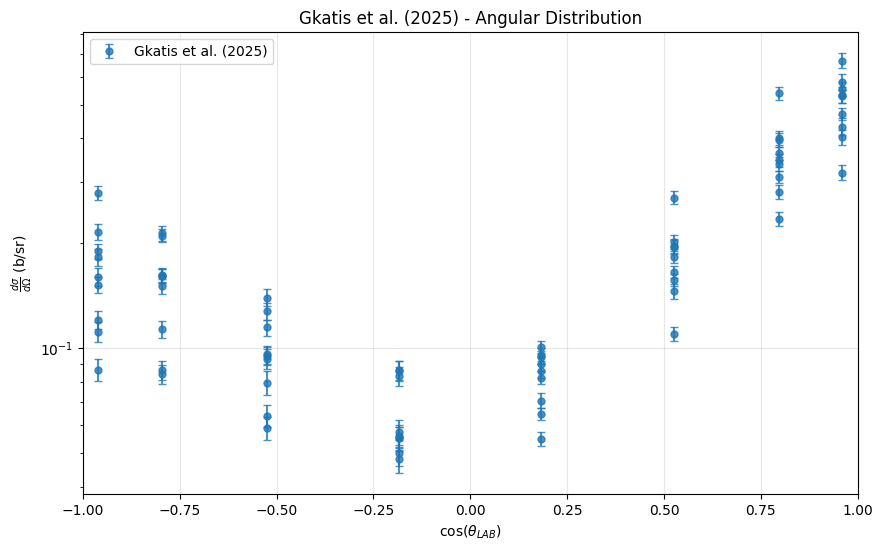

In [34]:
# Quick plot at single energy using the object method
# Default: cos(theta) x-axis from -1 to 1, log y-axis
fig, ax = plt.subplots(figsize=(10, 6))

energies_arr = exfor.energies()
exfor.plot(energy=energies_arr[10], ax=ax)

plt.title(f"{exfor.label} - Angular Distribution")
plt.show()

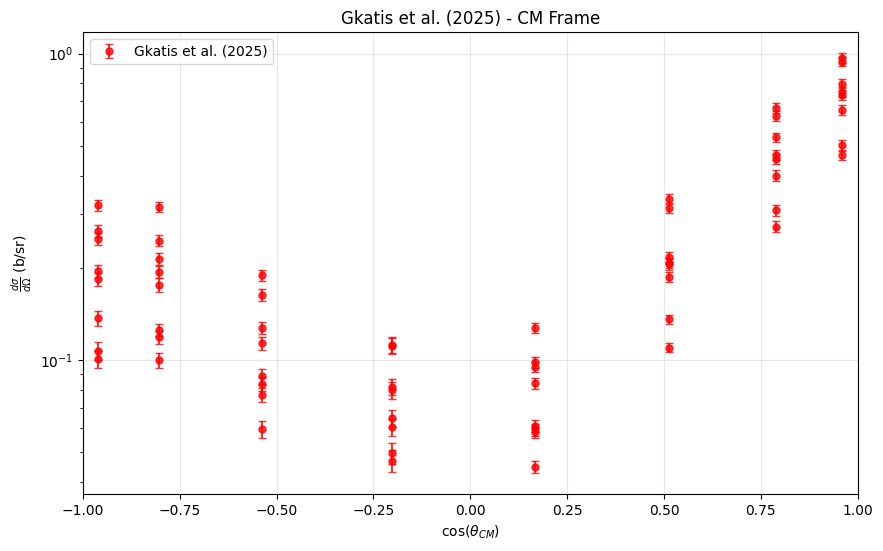

In [35]:
# Using the standalone plotting function
# Default: cos(theta) x-axis, log y-axis
fig, ax = plt.subplots(figsize=(10, 6))

# Plot in CM frame
exfor_cm = exfor.convert_to_cm()
plot_exfor_angular(exfor_cm, energy=1.5, ax=ax, use_mev=True, color='red')

plt.title(f"{exfor.label} - CM Frame")
plt.show()

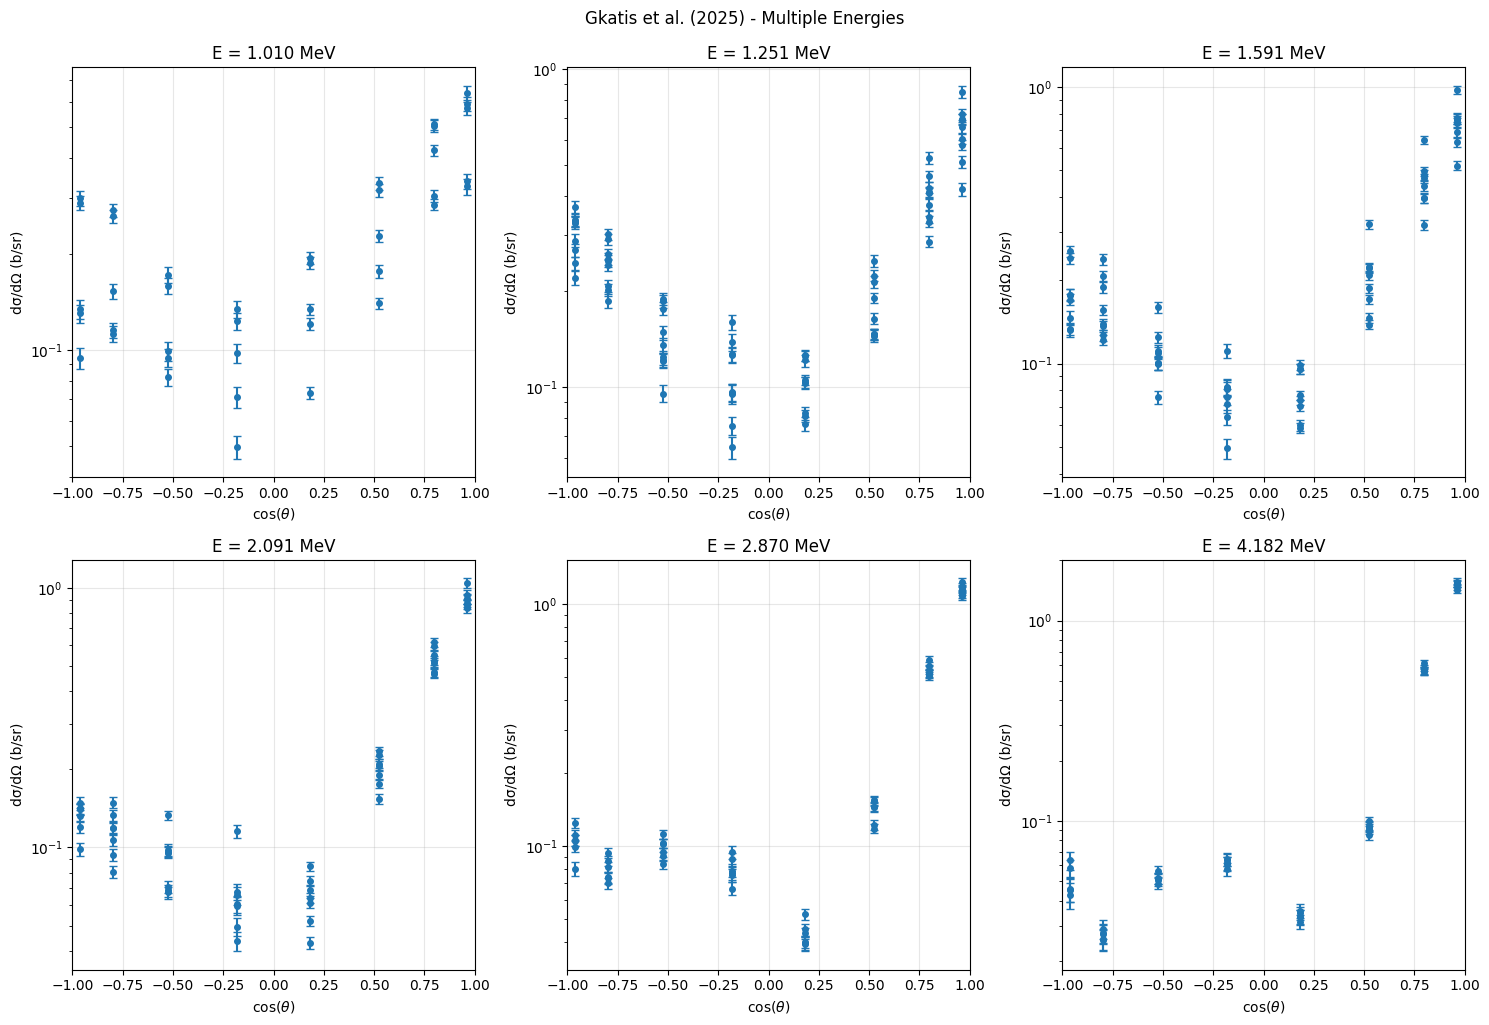

In [36]:
# Plot multiple energies using to_dataframe
# Default: cos(theta) x-axis from -1 to 1, log y-axis
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

energies_arr = exfor.energies()
plot_energies = energies_arr[::20][:6]  # Every 20th energy, first 6

for i, e in enumerate(plot_energies):
    ax = axes[i]
    df = exfor.to_dataframe(energy=e)
    
    # Convert angle to cosine
    cos_theta = np.cos(np.radians(df['angle'].values))
    
    ax.errorbar(cos_theta, df['value'], yerr=df['error'], 
                fmt='o', capsize=3, markersize=4)
    ax.set_title(f'E = {e:.3f} MeV')
    ax.set_xlabel(r'$\cos(\theta)$')
    ax.set_ylabel('dσ/dΩ (b/sr)')
    ax.set_xlim(-1, 1)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle(f'{exfor.label} - Multiple Energies', y=1.02)
plt.show()

## Summary

### Simplified EXFOR Module Structure

| Component | Description |
|-----------|-------------|
| `ExforEntry` | Base class with metadata as dicts |
| `ExforAngularDistribution` | Angular distribution data with conversions |
| `read_exfor()` | Load single file |
| `read_all_exfor()` | Load directory of files |

### Key Features

- **Properties** for common access: `label`, `target`, `zaid`, `process`
- **Dict access** for full metadata: `citation`, `reaction`, `facility`, `method`
- **Data discovery**:
  - `energies(unit='MeV', bounds=None)` - returns numpy array of unique energies
  - `angles(unit='deg', energy=None, bounds=None)` - returns numpy array of unique angles
- **Data access**: `to_dataframe()` - returns DataFrame with `energy`, `angle`, `value`, `error` columns
  - Filter by single energy: `to_dataframe(energy=1.5)`
  - Filter by energy range: `to_dataframe(energy=(1.0, 2.0))`
  - Filter by angle: `to_dataframe(angle=90)` or `to_dataframe(angle=(0, 90))`
  - Combined filters: `to_dataframe(energy=1.5, angle=(0, 90))`
  - Unit conversion: `to_dataframe(energy_unit='keV', cross_section_unit='mb/sr')`
- **Frame conversion**: `convert_to_cm()`, `convert_to_lab()`
- **Unit conversion**: `convert_energy()`, `convert_cross_section()`, `convert_angle()`
- **Static transforms**: `ExforAngularDistribution.transform_lab_to_cm()`, etc.
- **Energy resolution**: `compute_energy_resolution()`
- **Serialization**: `to_dict()`, `to_json()`

### Immutability

All conversion methods return **new objects** by default.
Use `inplace=True` to modify in place.